In [139]:
# limit the thread used by numpy for better parallelization
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"

In [140]:
import scipy.interpolate as interp 
try:
    import cupy as xp
    import cupyx.scipy.interpolate as xinterp
    print("has cupy")
except (ImportError, ModuleNotFoundError) as e:
    import numpy as xp
    import scipy.interpolate as xinterp  
    print("no cupy ")

from Triangle.Constants import *
from Triangle.FFTTools import *
from Triangle.Noise import *
from Triangle.Orbit import *
from Triangle.TDI import *
from Triangle.GW import *
from Triangle.Cosmology import LuminosityDistance, z_dl

# import matplotlib
# matplotlib.rcParams['text.usetex'] = True
# matplotlib.rcParams['font.family'] = 'serif'
import matplotlib.pyplot as plt

# import multiprocessing
# if __name__ == "__main__":
#     multiprocessing.set_start_method("fork")
# print("number of cpus =", multiprocessing.cpu_count())
# pool = multiprocessing.Pool(processes=multiprocessing.cpu_count())

no cupy 


In [141]:
from phenomxpy.phenomt import PhenomT, PhenomTHM
from phenomxpy.utils import MasstoSecond, SecondtoMass, AmpNRtoSI, AmpSItoNR, ModeToString, SpinWeightedSphericalHarmonic
from phenomxpy.fft import SimInspiralChirpStartFrequencyBound

In [142]:
class MBHB_Injection_PhenT:
    def __init__(self, mode="primary", use_gpu=False):
        if mode=="primary":
            self.mode_array = [[2,2],[2,-2]]
            self.max_m = 2. 
        elif mode == "full": 
            self.mode_array = None 
            self.max_m = 5. 
        else: 
            raise ValueError("mode not supported.")
        
        self.use_gpu=use_gpu
        if self.use_gpu:
            self.xp = xp 
        else: 
            self.xp = np 

    def __call__(self, parameters, times, f_lower=None, f_ref=None, use_internal_time=True):
        
        # convert input parameters to the parameters supported by phenomT
        m1 = m1_Mc_q(parameters["chirp_mass"], parameters["mass_ratio"]) # in MSUN 
        m2 = m1 * parameters["mass_ratio"] # in MSUN 
        M = m1 + m2 # in MSUN 
        eta = eta_q(parameters["mass_ratio"]) # dimensionless
        
        # set time series 
        if f_lower is None:
            Tobs = times[-1] - times[0] # in second
            buffered_Tobs_SI = 1.2 * Tobs 
            # f_lower = max(5e-5, SimInspiralChirpStartFrequencyBound(tchirp=buffered_Tobs_SI, m1=m1*MSUN, m2=m2*MSUN))
            f_lower = SimInspiralChirpStartFrequencyBound(tchirp=buffered_Tobs_SI, m1=m1*MSUN, m2=m2*MSUN)
        # wf_dt = parameters["chirp_mass"] * 1e-4 / self.max_m # an empirical setup of time step
        wf_dt = parameters["chirp_mass"] * 2e-5 # an empirical setup of time step
        
        # set waveform parameters
        wf_params = dict(
            delta_t_sec = wf_dt, 
            f_lower=f_lower, 
            total_mass=M, 
            eta=eta, 
            s1=[0., 0., parameters["spin_1z"]], 
            s2=[0., 0., parameters["spin_2z"]], 
            f_ref=f_ref # if None, then f_ref = f_lower 
        )
            
        # initialize phenomT waveform 
        phenT = PhenomTHM(
            **wf_params, 
            mode_array=self.mode_array,
            cuda=self.use_gpu, 
            numba_ansatzaes=False, 
            )
        
        # calculate polarizations 
        if use_internal_time:
            # the internal time of PhenT sets max amplitude at t=0
            wf_times_SI = MasstoSecond(phenT.times, M) + parameters["coalescence_time"] * DAY
            return_time_idx = self.xp.where(wf_times_SI>=0.)[0]
            wf_times_SI = wf_times_SI[return_time_idx] # only keep times after t=0
            hp, hc = phenT.compute_polarizations(
                inclination=parameters["inclination"], 
                phiRef=parameters["coalescence_phase"], # at f_ref, not at coalescence if f_ref != f_coal 
                # times=None, 
                times=phenT.times[return_time_idx], # only keep times after t=0
                distance=parameters["luminosity_distance"], 
                total_mass=M, 
            )
        else: 
            wf_times_SI = times 
            hp, hc = phenT.compute_polarizations(
                inclination=parameters["inclination"], 
                phiRef=parameters["coalescence_phase"], # at f_ref, not at coalescence if f_ref != f_coal 
                times=SecondtoMass(times - parameters["coalescence_time"] * DAY, M), 
                distance=parameters["luminosity_distance"], 
                total_mass=M, 
            )

        return wf_times_SI, hp + 1.0j * hc 
    
    def get_f_lower_f_coal(self, parameters, times): 

        # convert input parameters to the parameters supported by phenomT
        m1 = m1_Mc_q(parameters["chirp_mass"], parameters["mass_ratio"]) # in MSUN 
        m2 = m1 * parameters["mass_ratio"] # in MSUN 
        M = m1 + m2 # in MSUN 
        eta = eta_q(parameters["mass_ratio"]) # dimensionless
        
        # set time series
        Tobs = times[-1] - times[0] # in second
        buffered_Tobs_SI = 1.2 * Tobs 
        # f_lower = max(5e-5, SimInspiralChirpStartFrequencyBound(tchirp=buffered_Tobs_SI, m1=m1*MSUN, m2=m2*MSUN))
        f_lower = SimInspiralChirpStartFrequencyBound(tchirp=buffered_Tobs_SI, m1=m1*MSUN, m2=m2*MSUN)
        wf_dt = parameters["chirp_mass"] * 2e-5
        
        # set waveform parameters
        wf_params = dict(
            delta_t_sec = wf_dt, 
            f_lower=f_lower, 
            total_mass=M, 
            eta=eta, 
            s1=[0., 0., parameters["spin_1z"]], 
            s2=[0., 0., parameters["spin_2z"]], 
            f_ref=None # if None, then f_ref = f_lower 
        )
            
        # initialize phenomT waveform 
        phenT = PhenomTHM(
            **wf_params, 
            mode_array=[[2,2],[2,-2]], # only 22 mode is used to estimate f_coal
            cuda=self.use_gpu, 
            numba_ansatzaes=False, 
            )
        
        # calculate polarizations in the time domain 
        hp, hc = phenT.compute_polarizations(
            inclination=0., 
            phiRef=0., 
            times=None, 
            distance=1000., 
            total_mass=M, 
        )

        if self.use_gpu: 
            hp = hp.get() 
            hc = hc.get()

        f, hpf = FFT_window(
            data_array=hp, 
            fsample=1./wf_dt, 
        )
        _, hcf = FFT_window(
            data_array=hc, 
            fsample=1./wf_dt,
        )
        
        idx_coal = np.argmax(np.sqrt(np.abs(hpf) ** 2 + np.abs(hcf) ** 2) * f ** 2) # coalesence is defined at max f^2 * |h(f)|
        f_coal = f[idx_coal]
        return f_lower, f_coal

## Settings 

In [143]:
orbit = Orbit(OrbitDir="../OrbitData/MicroSateOrbitEclipticTCB")
Tobs = 15.*DAY
dt = 1. 
Tobs = int(Tobs/dt) * dt 
tcb_times = np.arange(int(Tobs / dt)) * dt

In [144]:
mbhb_parameters = {
    # 'chirp_mass': 1e5, 
    # 'chirp_mass': 1e6, 
    'chirp_mass': 1e7, 
    # 'mass_ratio': 0.6800360995621981,
    'mass_ratio': 0.1,
    'spin_1z': -0.39382065863038396,
    'spin_2z': 0.8223863508989862, 
    'coalescence_time': Tobs/DAY-1.,
    # 'coalescence_phase': 4.618102360940744,
    'coalescence_phase': 0.,
    'luminosity_distance': 13931.62935982271,
    'inclination': 1.8709099988987916,
    'longitude': 2.8373429551400404,
    'latitude': -0.6806154941973864,
    'psi': 1.6782894010201774,
}

In [145]:
mbhb_waveform_generator = MBHB_Injection_PhenT(
    # mode="primary", 
    mode="full", 
    use_gpu=False, 
)

mbhb_response_generator = FastMichelsonTDIResponse(
    orbit=orbit, 
    tcb_times=tcb_times, 
    use_gpu=False, 
    drop_points=int(1000./dt), 
    interp_method="Spline5",
)

mbhb_response_generator_approx1 = FastMichelsonTDIResponse(
    orbit=orbit, 
    tcb_times=tcb_times, 
    use_gpu=False, 
    drop_points=int(1000./dt), 
    interp_method="Spline3",
    # interp_method="linear",
)

mbhb_response_generator_approx2 = FastMichelsonTDIResponse(
    orbit=orbit, 
    tcb_times=tcb_times, 
    use_gpu=False, 
    drop_points=int(1000./dt), 
    # interp_method="Spline3",
    interp_method="linear",
    waveform_interp_order=5,
)

In [146]:
# initial run 
_ = mbhb_waveform_generator(
    parameters=mbhb_parameters, 
    times=tcb_times, 
)

In [147]:
for _ in range(20):
    t1, h1 = mbhb_waveform_generator(
        parameters=mbhb_parameters, 
        times=tcb_times, 
        use_internal_time=True, 
    )

In [148]:
for _ in range(20):
    t2, h2 = mbhb_waveform_generator(
        parameters=mbhb_parameters, 
        times=tcb_times, 
        use_internal_time=False, 
    )

In [149]:
f_lower, f_coal = mbhb_waveform_generator.get_f_lower_f_coal(
    parameters=mbhb_parameters, 
    times=tcb_times, 
)
f_lower, f_coal

(3.034538668673678e-05, 0.0002529291426445973)

In [150]:
for _ in range(20):
    t3, h3 = mbhb_waveform_generator(
        parameters=mbhb_parameters, 
        times=tcb_times, 
        f_lower=f_lower, 
        f_ref=f_coal, 
        use_internal_time=True, 
    )

14.032407407407407

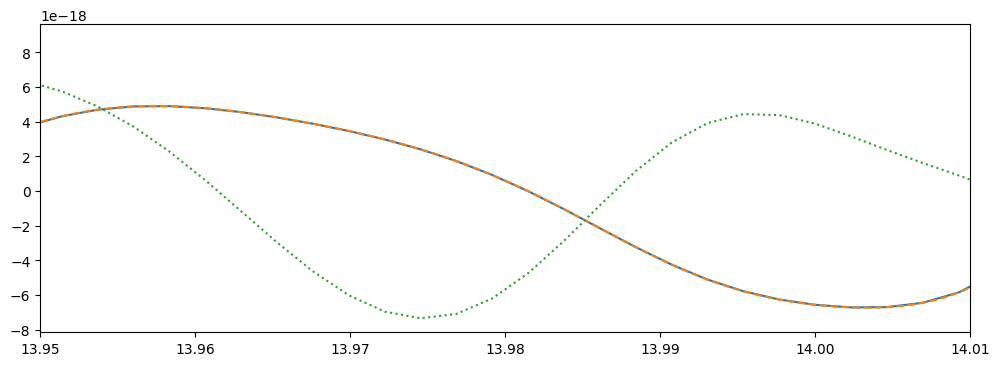

In [151]:
plt.figure(figsize=(12, 4))
plt.plot(t1/DAY, np.real(h1))
plt.plot(t2/DAY, np.real(h2), linestyle="--")
plt.plot(t3/DAY, np.real(h3), linestyle=":")
# plt.xlim(0, 15)
plt.xlim(13.95, 14.01)
# plt.xlim(13.995, 14.005)
# plt.vlines(14., -1e-19, 1e-19, linestyle="--")
t1[np.argmax(np.abs(h1))]/DAY

In [152]:
t1, t2, t3

(array([ 244200.,  244400.,  244600., ..., 1319000., 1319200., 1319400.]),
 array([0.000000e+00, 1.000000e+00, 2.000000e+00, ..., 1.295997e+06,
        1.295998e+06, 1.295999e+06]),
 array([ 244200.,  244400.,  244600., ..., 1319000., 1319200., 1319400.]))

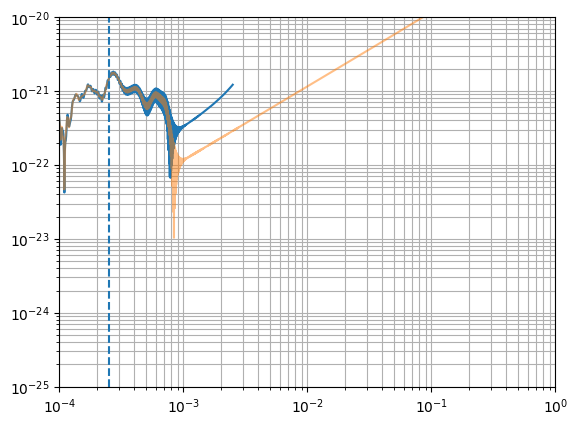

In [153]:
f1, hpf1 = FFT_window(
    data_array=np.real(h1), 
    fsample=1./(t1[1]-t1[0]), 
    # window_type="tukey",
    # window_args_dict=dict(alpha=0.1)
)
plt.loglog(f1, np.abs(hpf1) * f1**2)

f2, hpf2 = FFT_window(
    data_array=np.real(h2), 
    fsample=1./(t2[1]-t2[0]), 
    # window_type="tukey",
    # window_args_dict=dict(alpha=0.1)
)
plt.loglog(f2, np.abs(hpf2) * f2**2, alpha=0.5)
plt.vlines(f_coal, 1e-25, 1e-20, linestyle="--")
plt.ylim(1e-25, 1e-20)
plt.xlim(1e-4, 1)
plt.grid(which="both")

In [154]:
t1, t2

(array([ 244200.,  244400.,  244600., ..., 1319000., 1319200., 1319400.]),
 array([0.000000e+00, 1.000000e+00, 2.000000e+00, ..., 1.295997e+06,
        1.295998e+06, 1.295999e+06]))

In [155]:
tdi1 = mbhb_response_generator(
    parameters=mbhb_parameters, 
    waveform_generator=mbhb_waveform_generator,
    optimal_combination=True, 
    use_internal_time=True,
)

In [156]:
tdi2 = mbhb_response_generator(
    parameters=mbhb_parameters, 
    waveform_generator=mbhb_waveform_generator,
    optimal_combination=True, 
    use_internal_time=False,
)

In [157]:
tdi3 = mbhb_response_generator(
        parameters=mbhb_parameters, 
        waveform_generator=mbhb_waveform_generator,
        optimal_combination=True, 
        f_lower=f_lower, 
        f_ref=f_coal, 
        use_internal_time=True, 
)


In [158]:
tdi4 = mbhb_response_generator_approx1(
        parameters=mbhb_parameters, 
        waveform_generator=mbhb_waveform_generator,
        optimal_combination=True, 
        f_lower=f_lower, 
        f_ref=f_coal, 
        use_internal_time=True, 
)

In [159]:
tdi5 = mbhb_response_generator_approx2(
        parameters=mbhb_parameters, 
        waveform_generator=mbhb_waveform_generator,
        optimal_combination=True, 
        f_lower=f_lower, 
        f_ref=f_coal, 
        use_internal_time=True, 
)

In [160]:
tdi1.shape, tdi2.shape, tdi3.shape

((3, 1296000), (3, 1296000), (3, 1296000))

(13.9, 14.1)

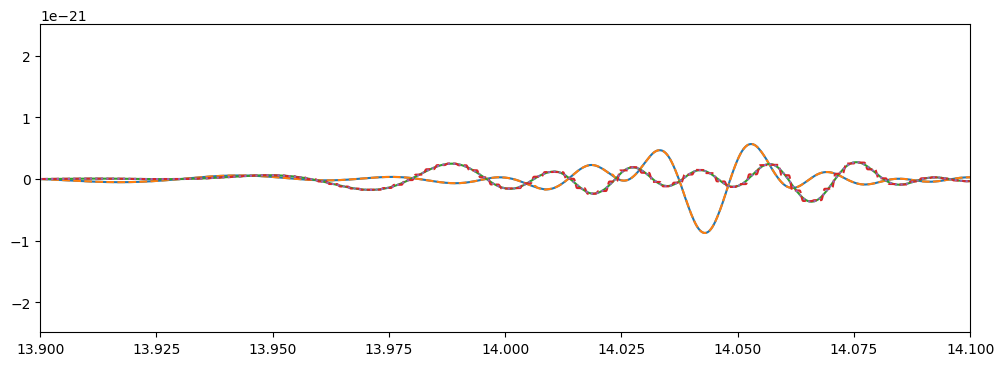

In [161]:
plt.figure(figsize=(12, 4))
plt.plot(tcb_times/DAY, tdi1[0])
plt.plot(tcb_times/DAY, tdi2[0], linestyle="--")
plt.plot(tcb_times/DAY, tdi3[0], linestyle="-")
plt.plot(tcb_times/DAY, tdi4[0], linestyle="--")
plt.plot(tcb_times/DAY, tdi5[0], linestyle=":")
plt.xlim(13.9, 14.1)
# plt.xlim(13.95, 14.01)
# plt.xlim(13.995, 14.005)

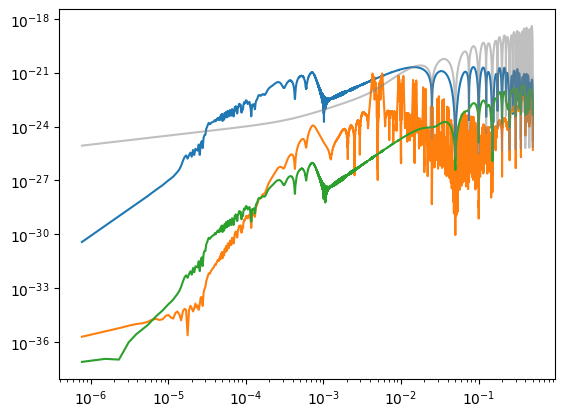

In [162]:
ff, xf = FFT_window(
    data_array=tdi3[0], 
    fsample=1./dt,
    window_type="tukey", 
    window_args_dict=dict(alpha=0.1)
)
plt.loglog(ff, np.abs(xf)*2.*ff)

ff, xf = FFT_window(
    data_array=tdi3[0]-tdi4[0], 
    fsample=1./dt,
    window_type="tukey", 
    window_args_dict=dict(alpha=0.1)
)
plt.loglog(ff, np.abs(xf)*2.*ff)

ff, xf = FFT_window(
    data_array=tdi3[0]-tdi5[0], 
    fsample=1./dt,
    window_type="tukey", 
    window_args_dict=dict(alpha=0.1)
)
plt.loglog(ff, np.abs(xf)*2.*ff)

psd_func = TDIPSDs()
plt.loglog(ff, np.sqrt(psd_func.PSD_A2(ff) * ff), color="grey", linestyle="-", alpha=0.5)

# plt.xlim(1e-4, 0.5)
# plt.ylim(1e-23,)